Author: Raphael Balzer  
GitHub Copilot was used to assist with code

In [ ]:
import sys
sys.path.insert(0, '..')

In [ ]:
# Configuration
CONFIG = {
    'dataset_path': '../data/train_test_network.csv',
    'enable_monitoring': True,
    'random_state': 42
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print("\n  Important: random_state must match training notebook to ensure same test set!")

Configuration:
  dataset_path: data/train_test_network.csv
  enable_monitoring: True
  random_state: 42

  Important: random_state must match training notebook to ensure same test set!


In [10]:
from ton_iot_pipeline import load_and_split_data

X_train, X_val, X_test, y_train, y_val, y_test, _, _, _ = load_and_split_data(
    filepath=CONFIG['dataset_path'],
    random_state=CONFIG['random_state']
)

Loading dataset...
Dataset shape: (211043, 44)
Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Data split (stratified by attack type):
  Train: 147,730 samples (70.0%)
  Val:   31,656 samples (15.0%)
  Test:  31,657 samples (15.0%)

Label distribution (0=normal, 1=attack):
  Train: 76.31% attacks
  Val:   76.31% attacks
  Test:  76.31% attacks


In [11]:
from preprocessing import CatBoostPreprocessor

preprocessor = CatBoostPreprocessor()
X_train_cat = preprocessor.fit_transform(X_train)
X_val_cat = preprocessor.transform(X_val)

c:\Users\rapha\Documents\projects\mal-ids-project\preprocessing.py:322: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('-', np.nan, inplace=True)


## Training

### No Hyperparameter Tuning

0:	learn: 0.9361299	total: 42ms	remaining: 4.16s
1:	learn: 0.9861442	total: 88ms	remaining: 4.31s
2:	learn: 0.9924086	total: 129ms	remaining: 4.17s
3:	learn: 0.9946017	total: 170ms	remaining: 4.09s
4:	learn: 0.9947380	total: 212ms	remaining: 4.03s
5:	learn: 0.9935338	total: 260ms	remaining: 4.07s
6:	learn: 0.9938241	total: 300ms	remaining: 3.98s
7:	learn: 0.9962082	total: 342ms	remaining: 3.93s
8:	learn: 0.9960460	total: 380ms	remaining: 3.84s
9:	learn: 0.9961383	total: 417ms	remaining: 3.75s
10:	learn: 0.9956878	total: 456ms	remaining: 3.69s
11:	learn: 0.9957459	total: 499ms	remaining: 3.66s
12:	learn: 0.9957907	total: 537ms	remaining: 3.59s
13:	learn: 0.9957729	total: 579ms	remaining: 3.56s
14:	learn: 0.9964406	total: 615ms	remaining: 3.49s
15:	learn: 0.9963820	total: 650ms	remaining: 3.41s
16:	learn: 0.9967032	total: 687ms	remaining: 3.36s
17:	learn: 0.9966798	total: 726ms	remaining: 3.31s
18:	learn: 0.9966977	total: 765ms	remaining: 3.26s
19:	learn: 0.9967757	total: 806ms	remaining

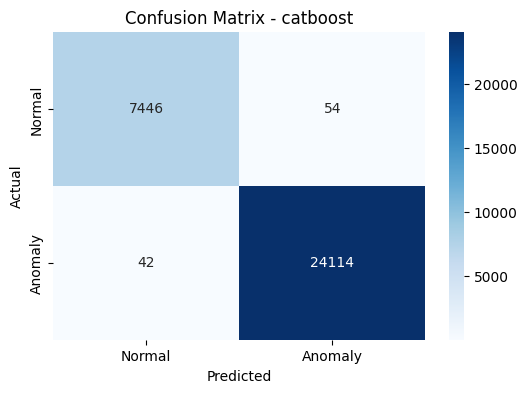

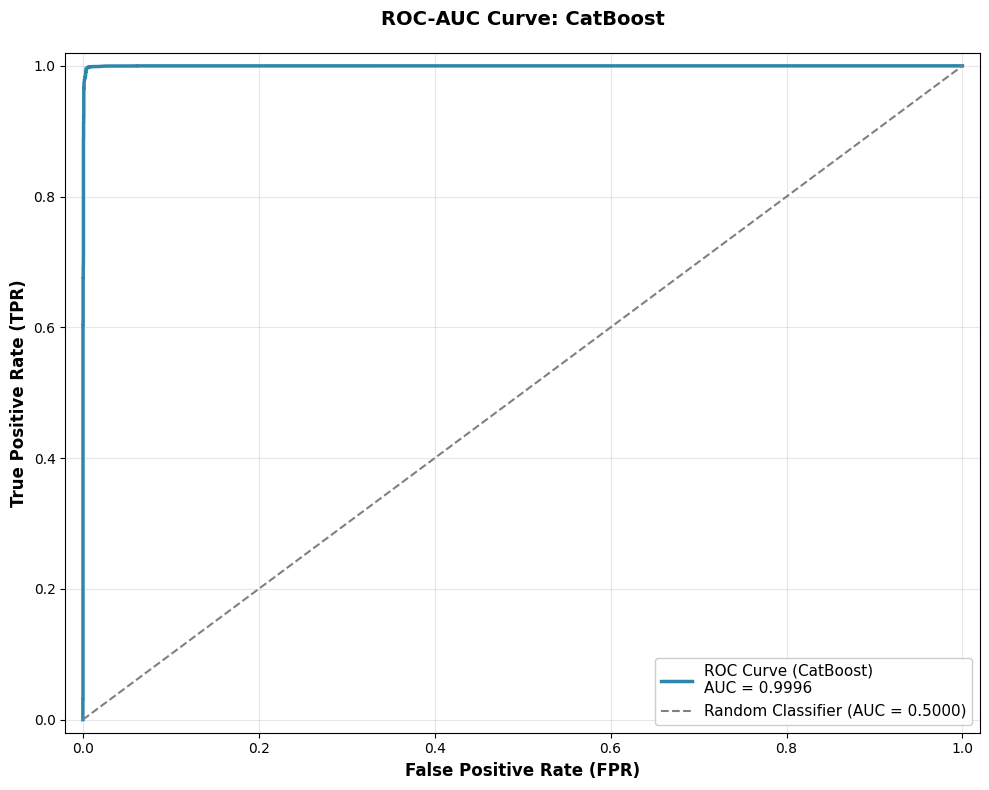


                           ROC-AUC ANALYSIS                           

Model:                  CatBoost
AUC Score:              0.999566
Total Samples:          31656
Positive Samples:       24156
Negative Samples:       7500




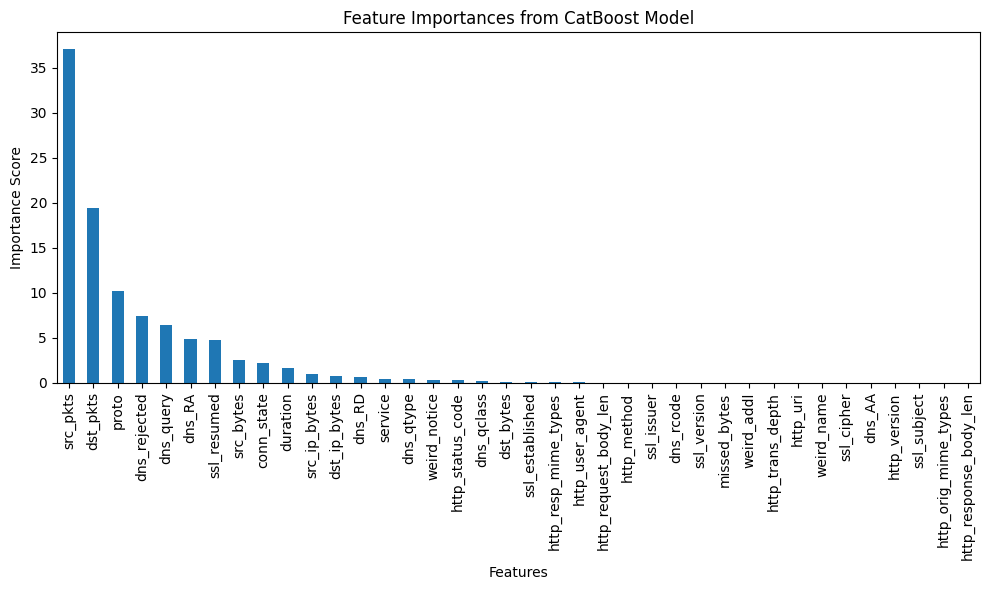

In [7]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix
from ton_iot_utils import plot_confusion_matrix, plot_roc_auc_curve
import pandas as pd
import matplotlib.pyplot as plt

train_pool = Pool(data=X_train_cat, label=y_train,
                  cat_features=preprocessor.categorical_cols)
test_pool = Pool(data=X_val_cat, label=y_val,
                 cat_features=preprocessor.categorical_cols)

model = CatBoostClassifier(iterations=100,
                           depth=2,
                           learning_rate=1,
                           loss_function='Logloss',
                           eval_metric='F:beta=2',
                           random_seed=42,
                           verbose=True)
# train the model
model.fit(train_pool)
# make the prediction using the resulting model
preds_class = model.predict(test_pool)
preds_proba = model.predict_proba(test_pool)
performance = classification_report(y_val, preds_class)
print(performance)
cm = confusion_matrix(y_val, preds_class)
plot_confusion_matrix(cm, "catboost")
results = plot_roc_auc_curve(y_val, y_pred_proba=preds_proba[:, 1], model_name="CatBoost")
importances = model.get_feature_importance()
feature_names = X_train_cat.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importances from CatBoost Model')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

checkpoint = {
    "model": model,
    "preprocessor": preprocessor
    }
with open(f"../model/catboost_small.pkl", "wb") as f:
    pickle.dump(checkpoint, f)
    print(f"Saved model to ../model/catboost_small.pkl")

Saved model to models/catboost_small.pkl


### Hyperparameter Tuning

[I 2026-01-21 18:44:33,246] A new study created in memory with name: no-name-c662d0ae-b45b-4efc-ab31-29e076844023


Training on fold [0/3]

bestTest = 0.9964055172
bestIteration = 163

Training on fold [1/3]

bestTest = 0.9963735364
bestIteration = 178

Training on fold [2/3]


[I 2026-01-21 18:45:48,602] Trial 0 finished with value: 0.9967733678153562 and parameters: {'learning_rate': 0.018180023539150943, 'depth': 4, 'l2_leaf_reg': 7}. Best is trial 0 with value: 0.9967733678153562.



bestTest = 0.9976168692
bestIteration = 275

Training on fold [0/3]

bestTest = 0.9962879843
bestIteration = 350

Training on fold [1/3]

bestTest = 0.9930950231
bestIteration = 10

Training on fold [2/3]


[I 2026-01-21 18:46:50,055] Trial 1 finished with value: 0.994100480425156 and parameters: {'learning_rate': 0.0071004009563865565, 'depth': 5, 'l2_leaf_reg': 2}. Best is trial 0 with value: 0.9967733678153562.


...


bestTest = 0.9952706114
bestIteration = 14

Training on fold [0/3]

bestTest = 0.9942776915
bestIteration = 5

Training on fold [1/3]

bestTest = 0.9942307181
bestIteration = 13

Training on fold [2/3]


[I 2026-01-21 19:12:37,225] Trial 8 finished with value: 0.9941774599659019 and parameters: {'learning_rate': 0.0011151724126810887, 'depth': 9, 'l2_leaf_reg': 2}. Best is trial 6 with value: 0.9988878631969461.



bestTest = 0.9949734592
bestIteration = 4

Training on fold [0/3]

bestTest = 0.9950433771
bestIteration = 3

Training on fold [1/3]

bestTest = 0.9941394513
bestIteration = 6

Training on fold [2/3]


[I 2026-01-21 19:13:19,769] Trial 9 finished with value: 0.9941434518128927 and parameters: {'learning_rate': 0.0029390433211157127, 'depth': 8, 'l2_leaf_reg': 7}. Best is trial 6 with value: 0.9988878631969461.



bestTest = 0.9943003584
bestIteration = 5

Beste Hyperparameter: {'learning_rate': 0.03507902116088658, 'depth': 10, 'l2_leaf_reg': 3}
Optimale Anzahl Iterationen (durch Early Stopping ermittelt): 360
0:	learn: 0.9935189	total: 462ms	remaining: 2m 46s
1:	learn: 0.9936853	total: 957ms	remaining: 2m 51s
2:	learn: 0.9937688	total: 1.44s	remaining: 2m 51s
3:	learn: 0.9947478	total: 1.97s	remaining: 2m 54s
4:	learn: 0.9944498	total: 2.46s	remaining: 2m 54s
5:	learn: 0.9952539	total: 2.97s	remaining: 2m 55s
6:	learn: 0.9954261	total: 3.52s	remaining: 2m 57s
7:	learn: 0.9953070	total: 4.02s	remaining: 2m 56s
8:	learn: 0.9953922	total: 4.57s	remaining: 2m 58s
9:	learn: 0.9952718	total: 5.12s	remaining: 2m 59s
10:	learn: 0.9958256	total: 5.72s	remaining: 3m 1s
11:	learn: 0.9957406	total: 6.21s	remaining: 2m 59s
12:	learn: 0.9957104	total: 6.67s	remaining: 2m 57s
13:	learn: 0.9957618	total: 7.11s	remaining: 2m 55s
14:	learn: 0.9958590	total: 7.63s	remaining: 2m 55s
15:	learn: 0.9959547	total: 8

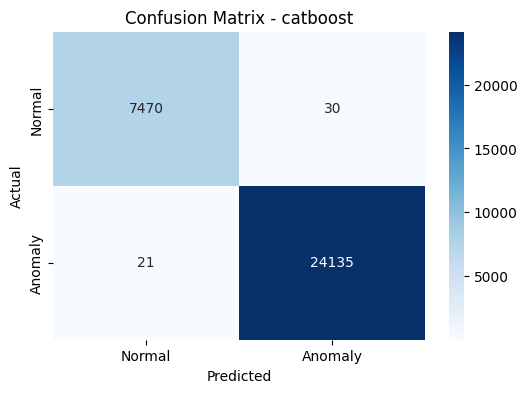

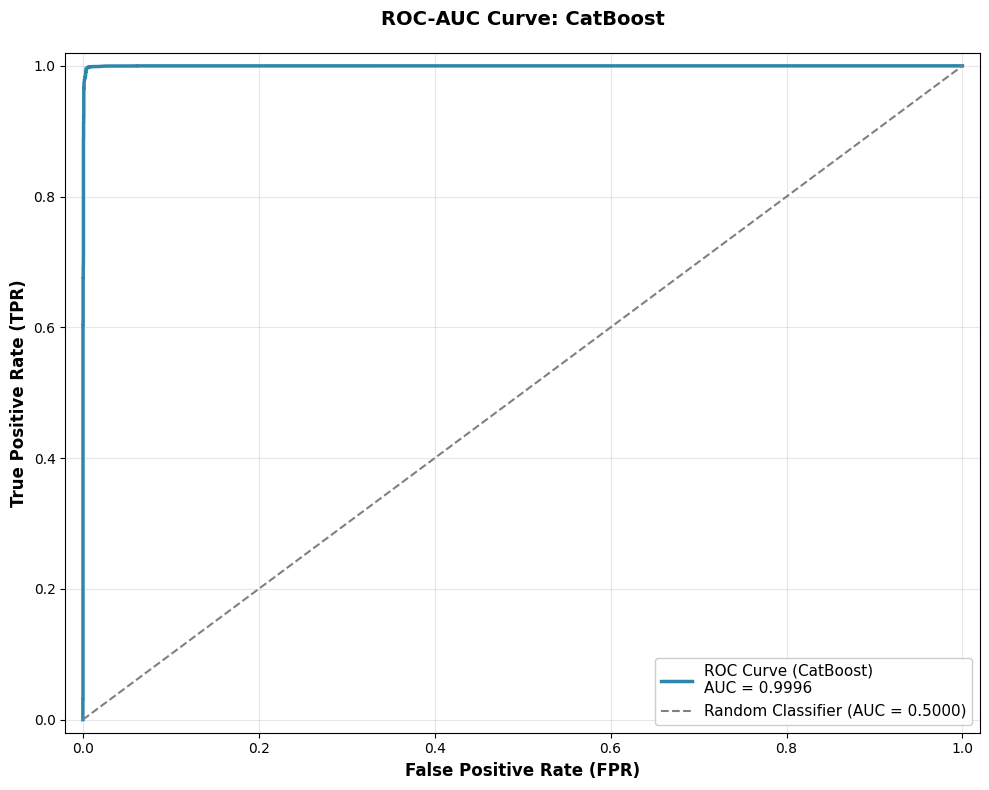


                           ROC-AUC ANALYSIS                           

Model:                  CatBoost
AUC Score:              0.999566
Total Samples:          31656
Positive Samples:       24156
Negative Samples:       7500




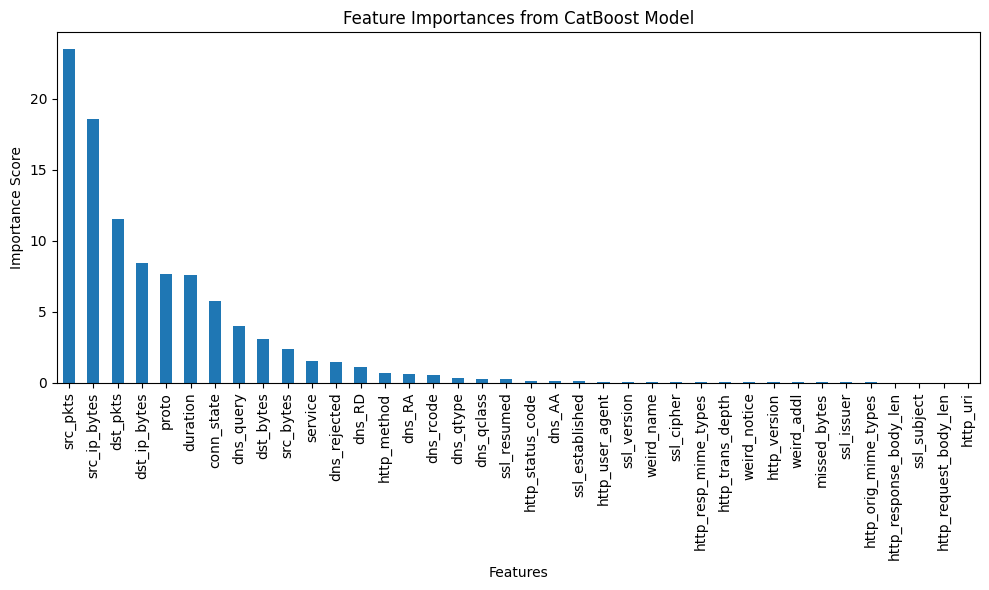

In [12]:
from catboost import CatBoostClassifier, Pool, cv
import optuna


train_pool = Pool(data=X_train_cat, label=y_train,
                  cat_features=preprocessor.categorical_cols)
test_pool = Pool(data=X_val_cat, label=y_val,
                 cat_features=preprocessor.categorical_cols)

def objective(trial):
    params = {
        "iterations": 1000, # Hohe Obergrenze
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 9),
        "loss_function": "Logloss",
        "eval_metric": "F:beta=2",
        "early_stopping_rounds": 50,
        "verbose": False
    }

    cv_data = cv(
        params=params,
        pool=train_pool,
        fold_count=3,
        shuffle=True,
        partition_random_seed=42,
        plot=False,
        verbose=False
    )
    
    # 1. Den besten Score finden
    metric_col = 'test-F:beta=2-mean'
    best_f2 = cv_data[metric_col].max()
    # 2. Die Iteration finden, bei der dieser Score erreicht wurde
    best_iteration = cv_data[metric_col].idxmax() + 1
    trial.set_user_attr("n_estimators", int(best_iteration))
    
    return best_f2

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Beste Hyperparameter:", study.best_params)

best_n_estimators = study.best_trial.user_attrs["n_estimators"]
print(f"Optimale Anzahl Iterationen (durch Early Stopping ermittelt): {best_n_estimators}")

final_params = study.best_params.copy()
final_params['iterations'] = best_n_estimators 

model = CatBoostClassifier(
    iterations=final_params['iterations'],
    learning_rate=final_params['learning_rate'],
    depth=final_params['depth'],
    l2_leaf_reg=final_params['l2_leaf_reg'],
    loss_function="Logloss",
    eval_metric="F:beta=2",
    verbose=True
)

model.fit(train_pool) # Training auf X_train mit exakter Iterationszahl
# Evaluate on validation set
preds_class = model.predict(test_pool)
print(classification_report(y_val, preds_class))
cm = confusion_matrix(y_val, preds_class)
plot_confusion_matrix(cm, "catboost")
results = plot_roc_auc_curve(y_val, y_pred_proba=preds_proba[:, 1], model_name="CatBoost")
importances = model.get_feature_importance()
feature_names = X_train_cat.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importances from CatBoost Model')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# saving model as pickle
import pickle

checkpoint = {
    "model": model,
    "preprocessor": preprocessor
    }
with open(f"../model/catboost_tuned.pkl", "wb") as f:
    pickle.dump(checkpoint, f)
    print(f"Saved model to ../model/catboost_tuned.pkl")

Saved model to models/catboost_tuned.pkl
